# P: EfficientNet + RoBERTa + Cross-Attention Fusion (23개 클래스)
B1, RT 가중치 로드 후 Cross-Attention 멀티모달 학습
백본 동결 + 분류 헤드만 학습 (전이학습)

## 0. 환경 설정

In [ ]:
!pip install tf_keras tensorflow_hub scikit-learn -q
!pip install transformers==4.40.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 134.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tf_keras as keras
from tf_keras import layers
import tensorflow as tf
import tensorflow_hub as hub
from transformers import AutoTokenizer, TFRobertaModel

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. 드라이브 마운트 및 경로 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = '/content/drive/MyDrive/multimodel_recycle/output'
TRAIN_CSV = os.path.join(BASE_DIR, 'train.csv')
VAL_CSV = os.path.join(BASE_DIR, 'val.csv')
TEST_CSV = os.path.join(BASE_DIR, 'test.csv')
B1_MODEL_PATH = os.path.join(BASE_DIR, 'b1_best.keras')
ROBERTA_MODEL_PATH = os.path.join(BASE_DIR, 'roberta_finetuned')

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-5
NUM_CLASS = 23
MAX_LEN = 64
NUM_HEADS = 8
PROJ_DIM = 768
SEED = 42

GROUP_NAMES = {
    0:  '종이', 1:  '종이팩', 2:  '종이컵', 3:  '캔',
    4:  '재사용유리', 5:  '유리', 6:  '페트', 7:  '플라스틱', 8:  '비닐',
    9:  '종이+이물질', 10: '종이컵+이물질', 11: '캔+이물질', 12: '유리+이물질',
    13: '페트+이물질+다중포장재', 14: '페트+이물질', 15: '플라스틱+이물질', 16: '비닐+이물질',
    17: '재사용유리+다중포장재', 18: '유리+다중포장재', 19: '페트+다중포장재',
    20: '스티로폼', 21: '스티로폼+이물질', 22: '건전지',
}
print('설정 완료')

설정 완료


## 2. 데이터 로드 및 토크나이징

In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df= pd.read_csv(TEST_CSV)

IMG_DIR = os.path.join(BASE_DIR, 'images')
def fix_path(x):
    filename = x.replace('\\', '/').split('/')[-1]
    return os.path.join(IMG_DIR, filename)

train_df['img_path'] = train_df['img_path'].apply(fix_path)
val_df['img_path'] = val_df['img_path'].apply(fix_path)
test_df['img_path'] = test_df['img_path'].apply(fix_path)

print(f'Train: {len(train_df)}장')
print(f'Val: {len(val_df)}장')
print(f'Test: {len(test_df)}장')

Train: 17250장
Val: 3450장
Test: 2300장


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_PATH)

def tokenize_texts(texts):
    encoded = tokenizer(
        list(texts),
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )
    return encoded['input_ids'], encoded['attention_mask']

train_input_ids, train_attn_mask = tokenize_texts(train_df['bert_text'])
val_input_ids,   val_attn_mask = tokenize_texts(val_df['bert_text'])
test_input_ids,  test_attn_mask = tokenize_texts(test_df['bert_text'])
print('토크나이징 완료')

토크나이징 완료


## 3. Dataset 생성

In [ ]:
def load_image(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)
    return img

def make_multimodal_dataset(df, input_ids, attn_mask, shuffle=False):
    img_paths = df['img_path'].values
    labels = df['group_id'].values.astype(np.int32)
    img_ds = tf.data.Dataset.from_tensor_slices(img_paths).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    txt_ds = tf.data.Dataset.from_tensor_slices((input_ids, attn_mask))
    label_ds = tf.data.Dataset.from_tensor_slices(labels)
    ds = tf.data.Dataset.zip(((img_ds, txt_ds), label_ds))
    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_multimodal_dataset(train_df, train_input_ids, train_attn_mask, shuffle=True)
val_ds = make_multimodal_dataset(val_df, val_input_ids,   val_attn_mask)
test_ds = make_multimodal_dataset(test_df, test_input_ids,  test_attn_mask)
print('Dataset 생성 완료')

Dataset 생성 완료


## 4. P 모델 구성 (B1+RT 가중치 로드 + Cross-Attention Fusion)

In [ ]:
roberta = TFRobertaModel.from_pretrained(ROBERTA_MODEL_PATH)
roberta.trainable = True

img_input = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image')

backbone = keras.applications.EfficientNetB0(include_top=False, pooling=None)
backbone.trainable = False

img_feat = backbone(img_input)
img_feat = layers.Reshape((49, 1280))(img_feat)
img_proj = layers.Dense(PROJ_DIM, name='img_projection')(img_feat)

input_ids_input = keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
attn_mask_input = keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')

txt_output = roberta(input_ids=input_ids_input, attention_mask=attn_mask_input)
txt_seq = txt_output.last_hidden_state

cross_attn = layers.MultiHeadAttention(
    num_heads=NUM_HEADS,
    key_dim=PROJ_DIM // NUM_HEADS,
    name='cross_attention'
)
fused = cross_attn(query=txt_seq, key=img_proj, value=img_proj)
fused = layers.GlobalAveragePooling1D()(fused)
fused = layers.Dropout(0.3)(fused)

x = layers.Dense(256, activation='relu')(fused)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASS, activation='softmax')(x)

model_p = keras.Model(
    inputs=[img_input, (input_ids_input, attn_mask_input)],
    outputs=outputs,
    name='P_CrossAttentionFusion'
)

# B1 가중치 로드
model_b1_loaded = keras.models.load_model(
    B1_MODEL_PATH,
    compile=False
)
backbone.set_weights(model_b1_loaded.get_layer('efficientnetb0').get_weights())

print('B1 가중치 로드 완료')

model_p.summary()

All model checkpoint layers were used when initializing TFRobertaModel.

All the layers of TFRobertaModel were initialized from the model checkpoint at /content/drive/MyDrive/multimodel_recycle/output/roberta_finetuned.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


16705208/16705208 [==============================] - 0s 0us/step
B1 가중치 로드 완료
Model: "P_CrossAttentionFusion"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image (InputLayer)          [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 efficientnetb0 (Functional  (None, None, None, 1280)     4049571   ['image[0][0]']               
 )                                                                                                
                                                                                                  
 input_ids (InputLayer)      [(None, 64)]                 0         []                            
                                                                                                  

## 5. 모델 학습

In [ ]:
model_p.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR, weight_decay=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    keras.callbacks.ModelCheckpoint('p_best.keras', save_best_only=True, monitor='val_loss'),
    keras.callbacks.ModelCheckpoint(
        os.path.join(BASE_DIR, 'p_best.keras'),
        save_best_only=True,
        monitor='val_loss'
    ),
]

hist = model_p.fit(
    train_ds, epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/30


1079/1079 [==============================] - ETA: 0s - loss: 2.3030 - accuracy: 0.3263

/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


1079/1079 [==============================] - 763s 562ms/step - loss: 2.3030 - accuracy: 0.3263 - val_loss: 1.7116 - val_accuracy: 0.4832
Epoch 2/30
1079/1079 [==============================] - 112s 99ms/step - loss: 1.7544 - accuracy: 0.4532 - val_loss: 1.5148 - val_accuracy: 0.5310
Epoch 3/30
1079/1079 [==============================] - 135s 120ms/step - loss: 1.6005 - accuracy: 0.5021 - val_loss: 1.4105 - val_accuracy: 0.5571
Epoch 4/30
1079/1079 [==============================] - 135s 121ms/step - loss: 1.4852 - accuracy: 0.5299 - val_loss: 1.3376 - val_accuracy: 0.5742
Epoch 5/30
1079/1079 [==============================] - 135s 121ms/step - loss: 1.4071 - accuracy: 0.5548 - val_loss: 1.2823 - val_accuracy: 0.5838
Epoch 6/30
1079/1079 [==============================] - 135s 121ms/step - loss: 1.3407 - accuracy: 0.5728 - val_loss: 1.2521 - val_accuracy: 0.6006
Epoch 7/30
1079/1079 [==============================] - 134s 120ms/step - loss: 1.2907 - accuracy: 0.5851 - val_loss: 1.2139

## 6. 학습 곡선

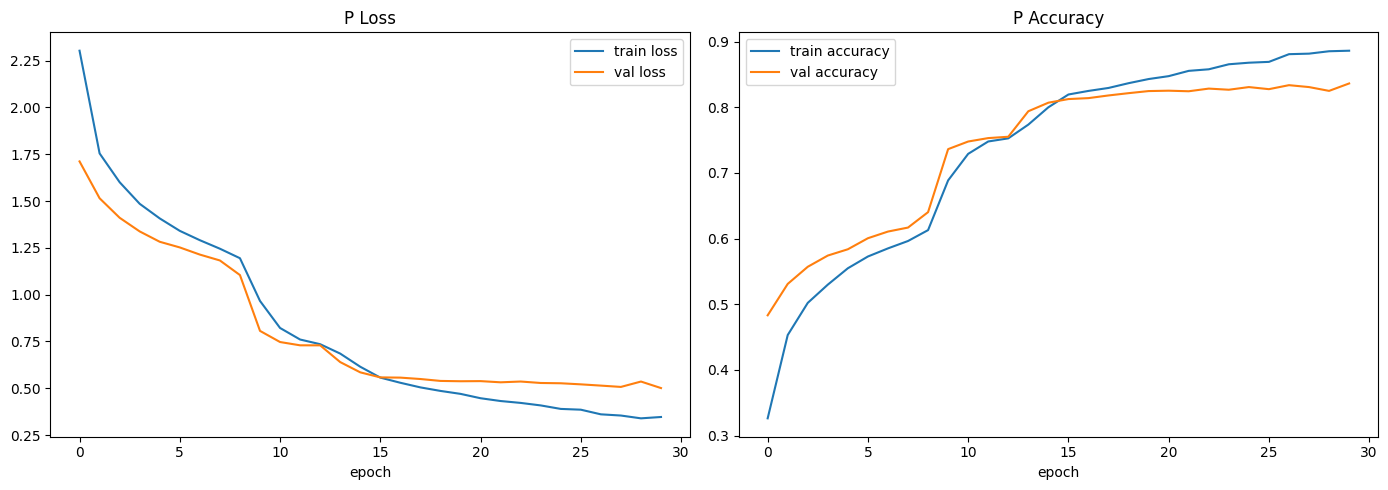

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].plot(hist.history['loss'],     label='train loss')
axs[0].plot(hist.history['val_loss'], label='val loss')
axs[0].set_title('P Loss'); axs[0].set_xlabel('epoch'); axs[0].legend()
axs[1].plot(hist.history['accuracy'],     label='train accuracy')
axs[1].plot(hist.history['val_accuracy'], label='val accuracy')
axs[1].set_title('P Accuracy'); axs[1].set_xlabel('epoch'); axs[1].legend()
plt.tight_layout()
plt.savefig('p_training_curve.png', dpi=150)
plt.show()

## 7. 텍스트 의존도 검사

In [ ]:
# 텍스트 자리에 zero tensor 넣어서 이미지만으로 테스트
def make_dummy_txt_dataset(df, input_ids, attn_mask):
    img_paths = df['img_path'].values
    labels = df['group_id'].values.astype(np.int32)
    img_ds = tf.data.Dataset.from_tensor_slices(img_paths).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    dummy_ids = tf.zeros_like(input_ids)
    dummy_mask = tf.zeros_like(attn_mask)
    txt_ds = tf.data.Dataset.from_tensor_slices((dummy_ids, dummy_mask))
    label_ds = tf.data.Dataset.from_tensor_slices(labels)
    ds = tf.data.Dataset.zip(((img_ds, txt_ds), label_ds))
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

dummy_ds = make_dummy_txt_dataset(test_df, test_input_ids, test_attn_mask)
y_pred = np.argmax(model_p.predict(dummy_ds), axis=1)
print(f'이미지만: {accuracy_score(y_true, y_pred):.4f}')

144/144 [==============================] - 16s 108ms/step
이미지만: 0.3874


## 8. 성능 평가 및 저장

In [ ]:
model_p = keras.models.load_model(
    'p_best.keras',
    custom_objects={'TFRobertaModel': TFRobertaModel}
)

y_pred = np.argmax(model_p.predict(test_ds), axis=1)
y_true = test_df['group_id'].values

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy:.4f}')
print(f'Macro F1: {macro_f1:.4f}')
print(classification_report(y_true, y_pred, target_names=list(GROUP_NAMES.values())))

model_p.save(os.path.join(BASE_DIR, 'p_best.keras'))
pd.DataFrame([{'model': 'P', 'accuracy': accuracy, 'macro_f1': macro_f1}]).to_csv(
    os.path.join(BASE_DIR, 'p_results.csv'), index=False
)
print('저장 완료')

144/144 [==============================] - 93s 468ms/step
Accuracy: 0.8322
Macro F1: 0.8315
              precision    recall  f1-score   support

          종이       0.76      0.68      0.72       100
         종이팩       0.69      0.71      0.70       100
         종이컵       0.67      0.83      0.74       100
           캔       0.71      0.82      0.76       100
       재사용유리       0.88      0.92      0.90       100
          유리       0.87      0.81      0.84       100
          페트       0.92      0.93      0.93       100
        플라스틱       0.81      0.64      0.72       100
          비닐       0.79      0.67      0.72       100
      종이+이물질       0.86      0.86      0.86       100
     종이컵+이물질       0.81      0.83      0.82       100
       캔+이물질       0.84      0.73      0.78       100
      유리+이물질       0.91      0.92      0.92       100
페트+이물질+다중포장재       0.88      0.89      0.89       100
      페트+이물질       0.84      0.88      0.86       100
    플라스틱+이물질       0.70      0.73      0.72

/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


저장 완료


## 9. 허깅페이스 업로드

In [ ]:
!pip install huggingface_hub -q

from huggingface_hub import HfApi

TOKEN = userdata.get('HF_TOKEN')
REPO_ID = "huggingleg12/BertEfficient_recycle"

api = HfApi(token=TOKEN)

# 저장소 생성
api.create_repo("BertEfficient_recycle", repo_type="model", exist_ok=True)

# p_best.keras 업로드
api.upload_file(
    path_or_fileobj="/content/drive/MyDrive/multimodel_recycle/output/p_best.keras",
    path_in_repo="p_best.keras",
    repo_id=REPO_ID,
    repo_type="model",
    token=TOKEN
)

# roberta_finetuned 폴더 업로드
api.upload_folder(
    folder_path="/content/drive/MyDrive/multimodel_recycle/output/roberta_finetuned",
    path_in_repo="roberta_finetuned",
    repo_id=REPO_ID,
    repo_type="model",
    token=TOKEN
)

print("업로드 완료!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...cycle/output/p_best.keras:   0%|          |  558kB / 1.39GB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rta_finetuned/tf_model.h5:   1%|1         | 5.49MB /  443MB            

업로드 완료!
